# Lista 9 (9 pkt.)

In [50]:
import numpy as np
import hashlib
import matplotlib.pyplot as plt
import random

def inv(p, n):
    def extended_gcd(a, b):
        if a == 0:
            return b, 0, 1
        else:
            g, y, x = extended_gcd(b % a, a)
            return g, x - (b // a) * y, y

    g, x, y = extended_gcd(p, n)
    
    if g != 1:
        return None
    else:
        return x % n

## Zadanie 1 (1 pkt.)

Wczytaj dwa obrazki: 'Campin_Boze_Narodzenie1.png' oraz 'Campin_Boze_Narodzenie2.png' jeden z nich jest zgodny z oryginałem obrazu Roberta Campin a drugi jest lekko zmodyfikowany, rozponaj prawdziwy obraz obliczając jego funkcję skrótu SHA-256 i porównując ją do skrótu podanego poniżej (w postaci szesnastkowej), który odpowiada oryginałowi:

In [51]:
hash_original='2d08246bbb3a8f6b0c16b8d8effd2c783233a6a174496731dfff887bb41bc7e7'

Obrazek wczytaj za pomocą:

In [52]:
file = open('Campin_Boze_Narodzenie1.png','rb')
obraz1=file.read()
file.close()

'rb' w powyższej funkcji oznacza, że odczytujemy binarną postać obrazu. Podobnie wczytaj drugi obraz. Do policzenia funkcji skrótu użyj biblioteki hashlib: https://docs.python.org/3/library/hashlib.html

In [53]:
def check_image(filename, expected_hash):
    with open(filename, 'rb') as f:
        img_data = f.read()
        img_hash = hashlib.sha256(img_data).hexdigest()
        return img_hash == expected_hash, img_hash

is_original_1, hash1 = check_image('Campin_Boze_Narodzenie1.png', hash_original)
is_original_2, hash2 = check_image('Campin_Boze_Narodzenie2.png', hash_original)

print(f"Campin_Boze_Narodzenie1 match: {is_original_1} (Hash: {hash1})")
print(f"Campin_Boze_Narodzenie2 match: {is_original_2} (Hash: {hash2})")

if is_original_1:
    print("Campin_Boze_Narodzenie1.png to oryginał.")
else:
    print("Campin_Boze_Narodzenie2.png to oryginał.")

Campin_Boze_Narodzenie1 match: True (Hash: 2d08246bbb3a8f6b0c16b8d8effd2c783233a6a174496731dfff887bb41bc7e7)
Campin_Boze_Narodzenie2 match: False (Hash: cfd529c79a1fb0c015e6ff6f3015b3175b1281b992888f8f7718fe24f455a27b)
Campin_Boze_Narodzenie1.png to oryginał.


## Zadanie 2 (2 pkt.)

Zaimplementuj funkcję **rho_pollard()** znajdującą kolizje w funkcji skrótu za pomocą agorytmu rho Pollarda. Wypisz przykładowe pary argumentów, które mają taki sam skrót dla funkcji **simple_hash()**, która przyjmuje liczbę zapisaną szesnastkowo w postaci stringu i zwraca hash w postaci stringu z zapisem szesnastkowym.

In [54]:
def simple_hash(str):
    m = hashlib.sha256()
    m.update(bytes(int(str,16)))
    return m.hexdigest()[:2]

In [55]:
def rho_pollard():
    def f(x):
        return simple_hash(x)

    x = "1"
    y = "1"
    
    # Pętla wykrywająca cykl
    while True:
        x = f(x) # 1 krok
        y = f(f(y)) # 2 kroki
        
        # Jeśli wartości się spotkały, jesteśmy w cyklu
        if x == y:
            break

    seen = {}
    curr = "1"
    while True:
        h = simple_hash(curr)
        if h in seen:
            print(f"Kolizja znaleziona")
            print(f"Wejście A: {seen[h]}")
            print(f"Wejście B: {curr}")
            print(f"Hash: {h}")
            return seen[h], curr
        seen[h] = curr
        curr = hex(int(curr, 16) + 1)[2:]

rho_pollard()

Kolizja znaleziona
Wejście A: a
Wejście B: 17
Hash: 01


('a', '17')

## Zadanie 3 (2 pkt.)

Napisz funkcję **HMAC(K,M)**, która przyjmuje klucz oraz wiadomość a zwraca kod HMAC, wszystko w postaci stringu bitów. Funkcja **hash()** to funkcja SHA256 ale przyjmująca i zwracająca dane w postaci stringu bitów. Przyjmij długość bloku 64 bity (przypadek DESa).

In [56]:
def HMAC(K, M):
    B = 64
    
    # Padding
    ipad_byte = int('00110110', 2)
    opad_byte = int('01011100', 2)
    
    k_int = int(K, 2)
    
    # Tworzenie kluczy dopełnionych
    ipad_int = 0
    opad_int = 0
    for _ in range(8):
        ipad_int = (ipad_int << 8) | ipad_byte
        opad_int = (opad_int << 8) | opad_byte

    # Operacja XOR klucza z dopełnieniami    
    k_ipad_val = k_int ^ ipad_int
    k_opad_val = k_int ^ opad_int
    
    # Formatowanie do stringów binarnych
    k_ipad_bin = format(k_ipad_val, '064b')
    k_opad_bin = format(k_opad_val, '064b')
    
    # Wewnętrzne haszowanie: H((K ^ ipad) || message)
    inner_msg = k_ipad_bin + M
    inner_hash = hash(inner_msg)
    
    # Zewnętrzne haszowanie: H((K ^ opad) || inner_hash)
    outer_msg = k_opad_bin + inner_hash
    outer_hash = hash(outer_msg)
    
    return outer_hash

In [57]:
def hash(i):
    m = hashlib.sha256()
    m.update(int(i,2).to_bytes(len(i),'little'))
    return format(int(m.hexdigest(),16),'0256b')

In [58]:
print(HMAC('0010111000111100100000001100001000110000100011001110011110010000','0100011001010010011011010100100100011101011101111011010000101010')
    == '1101011010010010001001010001100000001011000100001100101110111010000001000000110000001111011111110101011101111010110111001111001001001010000011110101110101010000100011110100101000111001000111000011111000011111001001110000110001111100110011110010100110000100')
print(HMAC('1000110000100011001111011101000000010001110101110011101011000110','1100110101011010110010110011001001010000000000111000011011000011')
    == '0100010101000110011101000100111010101111011110001010001001011000010001011100010100000000010010110000100010010101011011000010111000001110000101100011101100111111001000101101110011101100001111000000011111011111100001010111010011010010101100010101011100111010')
print(HMAC('0010100101111010101111100000101110110001011111100101000010001010','1110001110111101101100001010001110011101011111101010110011000000')
    == '1101010101011101110011000000111100111100100100011001011000001011101001100011011011010100110100010110101100000011010100000100111100111111100001110100000100100111100011111011000110101010000101110001110111101110011001000010001001001010010011000000111000011111')

True
True
True


Zmienne **msg_enc1** oraz **msg_enc2** zawierają dwie wiadomości. Jedna z nich jest poprawna druga ma zmieniony jeden bit. Wiemy, że wiadomośc zaszyfrowano za pomocą DESa z kluczem **key** i nadawca dodał do niej kod HMAC zawarty w zmiennej $hmac$. Sprawdź, która z otrzymanych wiadomości jest poprawna.

In [59]:
msg_enc1 = '0110011010100110101010011000011111010000110111011011110110110101'
msg_enc2 = '0110011010100110101010011000011111010000110111010011110110110101'
key = '0001101100001110010010101101001101101010000100100000100001101100'

In [60]:
hmac = '1010011101011000110010101011100100001001110111010000110100110111001001110010001101001010000011010001001101010100000010100111110010101011001101001010101100110110000101101110100000010001101011011011110011110111011100110000011010110001110000011000011100101001'

In [61]:
calc_hmac1 = HMAC(key, msg_enc1)
calc_hmac2 = HMAC(key, msg_enc2)

print("Sprawdzanie msg_enc1.")
print(f"Obliczony: {calc_hmac1}")
print(f"Dostarczony:   {hmac}")
print(f"Zgodność: {calc_hmac1 == hmac}")

print("\nSprawdzanie msg_enc2.")
print(f"Obliczony: {calc_hmac2}")
print(f"Dostarczony:   {hmac}")
print(f"Zgodność: {calc_hmac2 == hmac}")

if calc_hmac1 == hmac:
    print("\nPoprawna wiadomość: msg_enc1")
elif calc_hmac2 == hmac:
    print("\nPoprawna wiadomość: msg_enc2")

Sprawdzanie msg_enc1.
Obliczony: 1010011101011000110010101011100100001001110111010000110100110111001001110010001101001010000011010001001101010100000010100111110010101011001101001010101100110110000101101110100000010001101011011011110011110111011100110000011010110001110000011000011100101001
Dostarczony:   1010011101011000110010101011100100001001110111010000110100110111001001110010001101001010000011010001001101010100000010100111110010101011001101001010101100110110000101101110100000010001101011011011110011110111011100110000011010110001110000011000011100101001
Zgodność: True

Sprawdzanie msg_enc2.
Obliczony: 0110110100000011011101001111101111001000101010101110010010000010010111110100001000110010100100110000100110010100010010000010011100010111101000100100110110110011101011101101101101001010001001000011010011010100000011100011111001011101100000000000111001011110
Dostarczony:   101001110101100011001010101110010000100111011101000011010011011100100111001000110100101000001101000100110101010000001

## Zadanie 4 (2 pkt.)

Napisz funkcję **sign(file_name, e, n)** generującą podpis elektroniczny pliku, gdzie **file_name** to nazwa pliku, $e$ i $n$ to klucz prywatny algorymtu RSA, oznaczenia jak na liście 7., funkcja ma zwracać podpis w postaci stringu z zapisem szesnastkowym.

In [62]:
def sign(file_name, d, n):
    """
    Generuje podpis cyfrowy pliku używając klucza prywatnego (d, n).
    """
    # 1. Wczytanie pliku binarnie
    with open(file_name, 'rb') as f:
        content = f.read()
    
    # 2. Obliczenie skrótu SHA-256
    h_obj = hashlib.sha256(content)
    h_hex = h_obj.hexdigest()
    
    # 3. Konwersja skrótu na liczbę całkowitą
    m = int(h_hex, 16)
    
    # 4. Obliczenie podpisu: s = m^d mod n
    s = pow(m, d, n)
    
    # 5. Zwrócenie podpisu jako string szesnastkowy
    return hex(s)[2:]

Napisz funkcję **check_sign(file_name, d, n, sign)** weryfikującą autentyczność podpisu, gdzie **file_name** to nazwa pliku $d$ i $n$ to klucz publiczny autora podpisu a $sign$ to podpis, funkcja ma zwracać **True** lub **False**.

In [63]:
def check_sign(file_name, e, n, sign):
    """
    Weryfikuje podpis cyfrowy pliku używając klucza publicznego (e, n).
    """
    # 1. Wczytanie pliku i obliczenie jego skrótu
    with open(file_name, 'rb') as f:
        content = f.read()
        
    h_obj = hashlib.sha256(content)
    m_expected = int(h_obj.hexdigest(), 16)
    
    # 2. Konwersja podpisu z hex na int
    s_int = int(sign, 16)
    
    # 3. Odszyfrowanie podpisu: m' = s^e mod n
    m_calculated = pow(s_int, e, n)
    
    # 4. Porównanie obliczonego skrótu z odszyfrowanym
    return m_expected == m_calculated

Wygeneruj klucze RSA z liczb pierwszych $p$ i $q$ i użyj ich w testach.

In [64]:
p=24130780476900131841553779066939443255102203937160657723394451174808141403858935238883126295228560935516885174421847238379397184900972008801015315248328437
q=26660613491521684005574100352062919789979599401844483402246984186988668019447679726081352452799126206997555710356464145743285983450292024894053538317854159

In [65]:
def key_gen(p, q):
    n = p * q
    phi = (p - 1) * (q - 1)
    e = 65537
    d = inv(e, phi)
    return (n, e, d)

n, e, d = key_gen(p, q)

In [66]:
print(sign('correlation.png',e,n)=='1d5e7cd47f75b13159a37c8ffb3ba7d9f43a21f4758ae06e856da0a468fd1772f7b8b52d0f948fd02610e0e05a54c0fff12d7bd27575583cfdf53b124e9c0e95df1de156aa0af52239f1329ab69000b4a6a61d3d45f190c4b9df4ca4b7d30904162727353a8fb09c9faf847eeb0f6f65394d92cb57ced2cdcff36c444394e3fff')
print(sign('Campin_Boze_Narodzenie1.png',e,n)=='1c6097177871bb4873fcd0ae658d28f46fcc54e4b0e595954a57c0008f8b86c7427cecf28296240025941fe2a019b80fcc5f43c4cae6b1d2163cecf8438336d3da6e33ae326dfa2c0e5ea7bbad511dd140bc7b0cd34829623bfd02bc66bc9b43d57443b7fd950bea5cb5f5df99d8611eeb0d4458b19809e3ff86abf6538c3e453')

True
True


In [67]:
print(check_sign('correlation.png',d,n,'1d5e7cd47f75b13159a37c8ffb3ba7d9f43a21f4758ae06e856da0a468fd1772f7b8b52d0f948fd02610e0e05a54c0fff12d7bd27575583cfdf53b124e9c0e95df1de156aa0af52239f1329ab69000b4a6a61d3d45f190c4b9df4ca4b7d30904162727353a8fb09c9faf847eeb0f6f65394d92cb57ced2cdcff36c444394e3fff')==True)
print(check_sign('correlation.png',d,n,'1d5e7cd47f75b13159a37c8ffb3ba7d9f43a21f4758ae06e856ba0a468fd1772f7b8b52d0f948fd02610e0e05a54c0fff12d7bd27575583cfdf53b124e9c0e95df1de156aa0af52239f1329ab69000b4a6a61d3d45f190c4b9df4ca4b7d30904162727353a8fb09c9faf847eeb0f6f65394d92cb57ced2cdcff36c444394e3fff')==False)
print(check_sign('Campin_Boze_Narodzenie1.png',d,n,'1c6097177871bb4873fcd0ae658d28f46fcc54e4b0e595954a57c0008f8b86c7427cecf28296240025941fe2a019b80fcc5f43c4cae6b1d2163cecf8438336d3da6e33ae326dfa2c0e5ea7bbad511dd140bc7b0cd34829623bfd02bc66bc9b43d57443b7fd950bea5cb5f5df99d8611eeb0d4458b19809e3ff86abf6538c3e453')==True)
print(check_sign('Campin_Boze_Narodzenie1.png',d,n,'1c6097177871bb4873fcd0ae658d28f46fec54e4b0e595954a57c0008f8b86c7427cecf28296240025941fe2a019b80fcc5f43c4cae6b1d2163cecf8438336d3da6e33ae326dfa2c0e5ea7bbad511dd140bc7b0cd34829623bfd02bc66bc9b43d57443b7fd950bea5cb5f5df99d8611eeb0d4458b19809e3ff86abf6538c3e453')==False)

True
True
True
True


## Zadanie 5 (2 pkt.)

"Kopanie" Bitcoina polega w uproszczeniu na szukaniu liczby dla której funkcja skrótu zwraca wartość mniejszą niż pewien próg, tzn. wartośc funkcji skrótu musi zaczynać się odpowiednią liczbą zer w zapisie bitowym. Jako, że funkcja skrótu ma właściwości pseudolosowe, szukamy tej liczby sprawdzając po kolei wszystkie liczby. Napisz funkcję **mine(d)**, szukającą takiej liczby $i$ dla której **SHA256(i)** zaczyna się w zapisie bitowym $d$ zerami. Podstawiaj kolejno liczby $0,1,2,3,...$. Funkcja ma zwracać liczbę dla której udało się spełnić warunek.

Uwaga: aby podać zmienną typu **int** jako argument do hashlib.sha256() należy przekonwerstować ją za pomocą **bytes()**

Wykonaj funkcję **mine(d)** dla kilkunastu wartości $d$ i narysuj wykres **plt.scatter()** zależności **i(d)**.

Uwaga: użyj skali logarytmicznej **plt.yscale('symlog')**.

Zastanów się ile teoretycznie (średnio) należy wykonać prób aby znaleźć funkcję skrótu z $d$ zerami na początku. Narysuj na wykresie linię obrazującą tą zależność i porównaj z punktami uzyskanymi z funkcji **mine()**.

Powtórz pomiary, ale zamiast brać kolejne liczby, bierz losowe. Sprawdź czy daje to lepsze rezultaty.

Kopanie...
Trudność 1: Znaleziono nonce 0 w 0.0000s
Trudność 2: Znaleziono nonce 3 w 0.0000s
Trudność 3: Znaleziono nonce 3 w 0.0000s
Trudność 4: Znaleziono nonce 3 w 0.0000s
Trudność 5: Znaleziono nonce 10 w 0.0000s
Trudność 6: Znaleziono nonce 10 w 0.0000s
Trudność 7: Znaleziono nonce 10 w 0.0000s
Trudność 8: Znaleziono nonce 1478 w 0.0012s
Trudność 9: Znaleziono nonce 1478 w 0.0012s
Trudność 10: Znaleziono nonce 1478 w 0.0013s
Trudność 11: Znaleziono nonce 1478 w 0.0015s
Trudność 12: Znaleziono nonce 2792 w 0.0024s
Trudność 13: Znaleziono nonce 11869 w 0.0104s
Trudność 14: Znaleziono nonce 53094 w 0.0524s
Trudność 15: Znaleziono nonce 53094 w 0.0464s
Trudność 16: Znaleziono nonce 188984 w 0.1687s
Trudność 17: Znaleziono nonce 210621 w 0.1833s
Trudność 18: Znaleziono nonce 255477 w 0.2367s
Trudność 19: Znaleziono nonce 255477 w 0.2388s
Trudność 20: Znaleziono nonce 255477 w 0.2370s
Trudność 21: Znaleziono nonce 728447 w 0.6452s
Trudność 22: Znaleziono nonce 728447 w 0.6528s
Trudność 

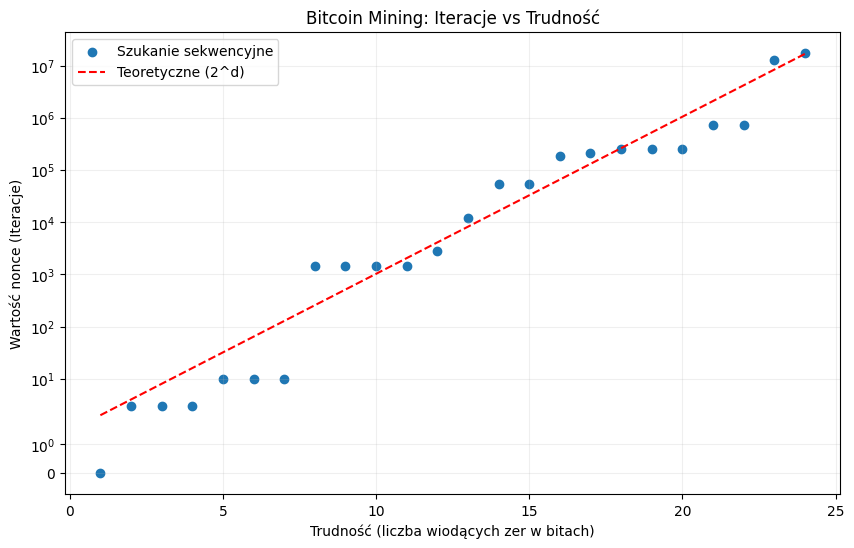

Kopanie z losowym nonce...


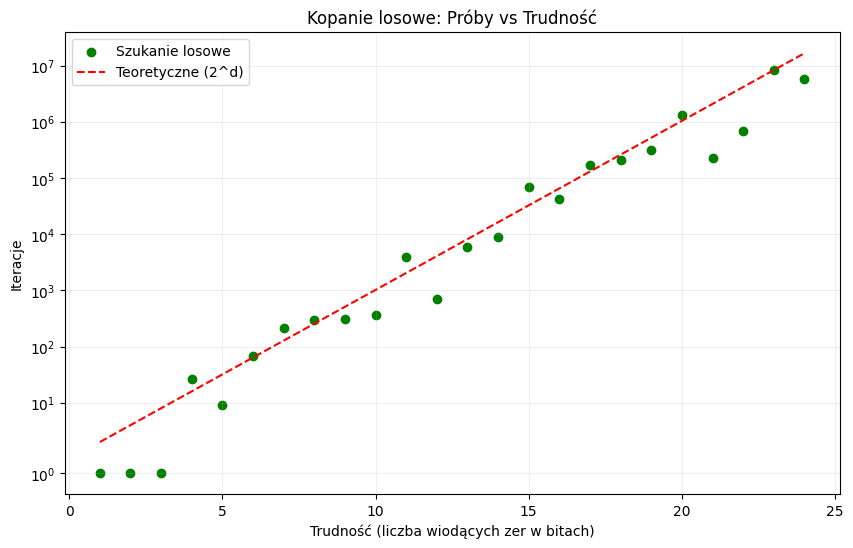

In [68]:
def mine(diff):
    """
    Szuka liczby (nonce), której skrót SHA256 zaczyna się od 'diff' liczby zer w zapisie binarnym.
    Sprawdzanie sekwencyjne (0, 1, 2...).
    """
    i = 0
    target_prefix = '0' * diff
    while True:
        length = (i.bit_length() + 7) // 8
        if length == 0: length = 1
        
        data_bytes = i.to_bytes(length, 'big')
        
        h_hex = hashlib.sha256(data_bytes).hexdigest()
        h_int = int(h_hex, 16)
        
        h_bin = format(h_int, '0256b')
        
        if h_bin.startswith(target_prefix):
            return i
        i += 1

# Zakres trudności do sprawdzenia (od 1 do 24 zer)
d_values = list(range(1, 25))
i_values = []
import time

print("Kopanie...")
for d in d_values:
    start = time.time()
    nonce = mine(d)
    end = time.time()
    i_values.append(nonce)
    print(f"Trudność {d}: Znaleziono nonce {nonce} w {end-start:.4f}s")

plt.figure(figsize=(10, 6))
plt.scatter(d_values, i_values, label='Szukanie sekwencyjne')
plt.yscale('symlog')
plt.xlabel('Trudność (liczba wiodących zer w bitach)')
plt.ylabel('Wartość nonce (Iteracje)')
plt.title('Bitcoin Mining: Iteracje vs Trudność')

# Linia teoretyczna: średnio trzeba sprawdzić 2^d hashy, aby znaleźć pasujący
theoretical = [2**d for d in d_values]
plt.plot(d_values, theoretical, 'r--', label='Teoretyczne (2^d)')

plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

def mine_random(diff):
    """
    To samo co mine(), ale nonce jest losowany (64 bity), a nie inkrementowany.
    """
    target_prefix = '0' * diff
    trials = 0
    while True:
        r = random.getrandbits(64)
        data_bytes = r.to_bytes(8, 'big')
        
        h_hex = hashlib.sha256(data_bytes).hexdigest()
        h_int = int(h_hex, 16)
        h_bin = format(h_int, '0256b')
        
        if h_bin.startswith(target_prefix):
            return trials
        trials += 1

print("Kopanie z losowym nonce...")
r_values = []
for d in d_values:
    trials = mine_random(d)
    r_values.append(trials)

plt.figure(figsize=(10, 6))
plt.scatter(d_values, r_values, color='green', label='Szukanie losowe')
plt.plot(d_values, theoretical, 'r--', label='Teoretyczne (2^d)')
plt.yscale('symlog')
plt.xlabel('Trudność (liczba wiodących zer w bitach)')
plt.ylabel('Iteracje')
plt.title('Kopanie losowe: Próby vs Trudność')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()